# EDA - Camada Bronze: `procedures_by_country`

Análise exploratória dos arquivos Parquet gerados na camada **Bronze** (ver [extracao_bronze_isaps.ipynb](extracao_bronze_isaps.ipynb)), referentes aos relatórios ISAPS (2018–2024).

A Bronze é extração tabular bruta — sem deduplicação, remoção de nulos ou validação de schema. O objetivo desta EDA é **mapear as transformações necessárias para a camada Silver**: duplicados, nulos, inconsistência de nomes de país entre relatórios de anos diferentes e o inventário completo de procedimentos (para decidir a tradução PT-BR).

Colunas esperadas: `arquivo_origem`, `ano_referencia`, `tipo_procedimento`, `categoria`, `procedimento`, `pais`, `quantidade`.

## 1. Imports e configuração

`BRONZE_DIR` aponta para a saída local de [extracao_bronze_isaps.ipynb](extracao_bronze_isaps.ipynb). `matplotlib` entra aqui (e não no notebook de extração) porque só é necessário para a seção de visualizações — EDA é o único lugar deste projeto que precisa plotar gráficos.

In [1]:
import glob
import os

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

BRONZE_DIR = os.path.join('..', 'dados_processados', 'bronze', 'procedures_by_country')

## 2. Carregamento dos arquivos bronze

Carrega **todos** os anos de uma vez, em vez de inspecionar arquivo por arquivo. É essa visão consolidada que permite enxergar problemas que só aparecem *entre* anos — como um mesmo país grafado de forma diferente em relatórios diferentes (seção 6.1) — que não seriam visíveis olhando um único arquivo isoladamente.

In [2]:
arquivos_parquet = sorted(glob.glob(os.path.join(BRONZE_DIR, '*.parquet')))
print(f'{len(arquivos_parquet)} arquivos encontrados:')
for f in arquivos_parquet:
    print(' -', os.path.basename(f))

7 arquivos encontrados:
 - 2018_isaps_global_survey_results_2018_1.parquet
 - 2019_global_survey_full_report_2019_english.parquet
 - 2020_isaps_global_survey_2020.parquet
 - 2021_isaps_global_survey_2021.parquet
 - 2022_isaps_global_survey_2022.parquet
 - 2023_isaps_global_survey_2023.parquet
 - 2024_isaps_global_survey_2024.parquet


In [3]:
dfs = [pd.read_parquet(f) for f in arquivos_parquet]
df = pd.concat(dfs, ignore_index=True)
print('Shape consolidado:', df.shape)

Shape consolidado: (5384, 7)


## 3. Visão geral do dataset

`head`/`tail`/`info`/`dtypes` são a primeira conferência de sanidade: as colunas são as esperadas (`arquivo_origem`, `ano_referencia`, `tipo_procedimento`, `categoria`, `procedimento`, `pais`, `quantidade`), os tipos batem (`quantidade` é `float`, não `object`) e não há sinal óbvio de que a extração da Bronze quebrou em algum lugar. `tail` complementa `head` porque os primeiros registros são sempre do mesmo PDF (o primeiro arquivo em ordem alfabética) — só olhando o fim do DataFrame concatenado dá pra ver um PDF diferente (aqui, `isaps-global-survey-2024.pdf`).

In [4]:
df.head(100)

,arquivo_origem,ano_referencia,tipo_procedimento,categoria,procedimento,pais,quantidade
0,isaps-global-survey-results-2018-1.pdf,2018,CIRURGICO,FACE & HEAD,Brow Lift,USA,24041.0
1,isaps-global-survey-results-2018-1.pdf,2018,CIRURGICO,FACE & HEAD,Brow Lift,BRAZIL,33883.0
2,isaps-global-survey-results-2018-1.pdf,2018,CIRURGICO,FACE & HEAD,Brow Lift,MEXICO,11377.0
3,isaps-global-survey-results-2018-1.pdf,2018,CIRURGICO,FACE & HEAD,Brow Lift,GERMANY,7128.0
4,isaps-global-survey-results-2018-1.pdf,2018,CIRURGICO,FACE & HEAD,Brow Lift,INDIA,8234.0
...,...,...,...,...,...,...,...
95,isaps-global-survey-results-2018-1.pdf,2018,CIRURGICO,BREAST,Breast Augmentation,ITALY,64976.0
96,isaps-global-survey-results-2018-1.pdf,2018,CIRURGICO,BREAST,Breast Augmentation,ARGENTINA,51081.0
97,isaps-global-survey-results-2018-1.pdf,2018,CIRURGICO,BREAST,Breast Augmentation,COLOMBIA,42774.0
98,isaps-global-survey-results-2018-1.pdf,2018,CIRURGICO,BREAST,Breast Augmentation,AUSTRALIA,17553.0


In [5]:
df.tail(10)

,arquivo_origem,ano_referencia,tipo_procedimento,categoria,procedimento,pais,quantidade
5374,isaps-global-survey-2024.pdf,2024,NAO-CIRURGICO,OTHER,Total Other Procedures,US,353995.0
5375,isaps-global-survey-2024.pdf,2024,NAO-CIRURGICO,OTHER,Total Other Procedures,VIETNAM,1740.0
5376,isaps-global-survey-2024.pdf,2024,NAO-CIRURGICO,OTHER,Total Non-Surgical Procedures,UAE,210752.0
5377,isaps-global-survey-2024.pdf,2024,NAO-CIRURGICO,OTHER,Total Non-Surgical Procedures,UK,22526.0
5378,isaps-global-survey-2024.pdf,2024,NAO-CIRURGICO,OTHER,Total Non-Surgical Procedures,US,4165645.0
5379,isaps-global-survey-2024.pdf,2024,NAO-CIRURGICO,OTHER,Total Non-Surgical Procedures,VIETNAM,62340.0
5380,isaps-global-survey-2024.pdf,2024,NAO-CIRURGICO,OTHER,Total SURGICAL & NON-SURGICAL Procedures,UAE,482752.0
5381,isaps-global-survey-2024.pdf,2024,NAO-CIRURGICO,OTHER,Total SURGICAL & NON-SURGICAL Procedures,UK,141134.0
5382,isaps-global-survey-2024.pdf,2024,NAO-CIRURGICO,OTHER,Total SURGICAL & NON-SURGICAL Procedures,US,6165173.0
5383,isaps-global-survey-2024.pdf,2024,NAO-CIRURGICO,OTHER,Total SURGICAL & NON-SURGICAL Procedures,VIETNAM,262620.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5384 entries, 0 to 5383
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   arquivo_origem     5384 non-null   object 
 1   ano_referencia     5384 non-null   int64  
 2   tipo_procedimento  5384 non-null   object 
 3   categoria          5384 non-null   object 
 4   procedimento       5384 non-null   object 
 5   pais               5384 non-null   object 
 6   quantidade         5382 non-null   float64
dtypes: float64(1), int64(1), object(5)
memory usage: 294.6+ KB


In [7]:
df.dtypes

arquivo_origem        object
ano_referencia         int64
tipo_procedimento     object
categoria             object
procedimento          object
pais                  object
quantidade           float64
dtype: object

## 4. Qualidade dos dados

Essas quatro checagens (nulos por coluna, percentual de nulos, linhas duplicadas, e combinações com valores conflitantes) são exatamente o que decide **duas** das transformações da camada Silver: quantos registros a etapa de remoção de nulos vai descartar, e se a deduplicação vai ter algo real para remover ou vai atuar apenas como proteção estrutural (ver a explicação da etapa 1 em [tratamento_silver_isaps.ipynb](tratamento_silver_isaps.ipynb)). A checagem de conflitos usa o mesmo critério da verificação de viabilidade da Bronze — combinações de chave com mais de um valor distinto de `quantidade` — agora sobre o dataset já consolidado.

In [8]:
# Valores nulos por coluna
df.isnull().sum()

arquivo_origem       0
ano_referencia       0
tipo_procedimento    0
categoria            0
procedimento         0
pais                 0
quantidade           2
dtype: int64

In [9]:
# Percentual de nulos
(df.isnull().mean() * 100).round(2)

arquivo_origem       0.00
ano_referencia       0.00
tipo_procedimento    0.00
categoria            0.00
procedimento         0.00
pais                 0.00
quantidade           0.04
dtype: float64

In [10]:
# Linhas totalmente duplicadas
print('Duplicadas:', df.duplicated().sum())

Duplicadas: 0


In [11]:
# Combinacoes pais/procedimento com valores conflitantes DENTRO do mesmo arquivo/ano
# (mesmo problema verificado na extracao Bronze -- aqui olhando o dataset ja consolidado)
chaves = ['arquivo_origem', 'tipo_procedimento', 'categoria', 'procedimento', 'pais']
conflitos = df.groupby(chaves)['quantidade'].nunique()
conflitos = conflitos[conflitos > 1]
print(f'Combinacoes com valores conflitantes: {len(conflitos)}')
conflitos.head(20)

Combinacoes com valores conflitantes: 0


Series([], Name: quantidade, dtype: int64)

## 5. Estatísticas descritivas

`describe()` e as estatísticas de `quantidade` (mínimo, máximo, média, mediana, desvio padrão) servem para detectar valores fora de escala antes de confiar em qualquer agregação — por exemplo, um máximo muito acima da média pode ser um outlier legítimo (like "Total Procedures" dos EUA, um agregado, não um procedimento individual) ou um sinal de erro de extração (um número lido errado do PDF). Sem essa checagem, um valor extremo passaria despercebido até aparecer distorcendo um gráfico ou uma soma na Silver.

In [12]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
arquivo_origem,5384,7,isaps-global-survey-2024.pdf,1568,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ano_referencia,5384.0,NaN,NaN,NaN,2021.798291,2.014574,2018.0,2020.0,2022.0,2024.0,2024.0
tipo_procedimento,5384,2,CIRURGICO,3562,NaN,NaN,NaN,NaN,NaN,NaN,NaN
categoria,5384,6,BODY & EXTREMITIES,1516,NaN,NaN,NaN,NaN,NaN,NaN,NaN
procedimento,5384,75,Brow Lift,125,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pais,5384,41,BRAZIL,294,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quantidade,5382.0,NaN,NaN,NaN,95072.877369,361968.269224,0.0,2332.25,10442.5,46019.5,7448196.0


In [13]:
# Estatísticas da coluna numérica 'quantidade'
print('Mínimo:', df['quantidade'].min())
print('Máximo:', df['quantidade'].max())
print('Média:', df['quantidade'].mean())
print('Mediana:', df['quantidade'].median())
print('Desvio padrão:', df['quantidade'].std())
print('Soma total:', df['quantidade'].sum())

Mínimo: 0.0
Máximo: 7448196.0
Média: 95072.87736900781
Mediana: 10442.5
Desvio padrão: 361968.2692240658
Soma total: 511682226.0


## 6. Dimensões categóricas

Conta quantos valores distintos existem em cada coluna categórica. Esse número não é só curiosidade — ele dimensiona o trabalho de tratamento na Silver: 41 países distintos (antes da normalização) é pouco o suficiente para revisar manualmente e achar duplicatas de grafia (seção 6.1); 75 procedimentos distintos é o tamanho exato do dicionário de tradução PT-BR que a Silver precisa (seção 8).

In [14]:
print('Anos de referência:', sorted(df['ano_referencia'].unique()))
print('Qtde de países (nomes distintos, sem normalizar):', df['pais'].nunique())
print('Qtde de tipos de procedimento:', df['tipo_procedimento'].nunique())
print('Qtde de categorias:', df['categoria'].nunique())
print('Qtde de procedimentos distintos:', df['procedimento'].nunique())

Anos de referência: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Qtde de países (nomes distintos, sem normalizar): 41
Qtde de tipos de procedimento: 2
Qtde de categorias: 6
Qtde de procedimentos distintos: 75


In [15]:
df['pais'].value_counts()

pais
BRAZIL            294
ITALY             294
MEXICO            294
GERMANY           294
INDIA             294
COLOMBIA          294
ARGENTINA         294
THAILAND          294
SPAIN             255
GREECE            255
JAPAN             213
TURKEY            164
USA               161
IRAN              133
US                133
FRANCE            131
ROMANIA           126
UK                 91
SOUTH AFRICA       91
MALAYSIA           91
BANGLADESH         91
TURKIYE            91
AUSTRALIA          88
UNITED KINGDOM     82
RUSSIA             80
SINGAPORE          49
TUNISIA            49
CHINESE TAIPEI     49
CHILE              49
CZECHIA            49
MOROCCO            49
PANAMA             49
NORWAY             49
UAE                49
VIETNAM            49
PHILIPPINES        49
SAUDI ARABIA       49
PERU               42
BELGIUM            42
SYRIA              42
VENEZUELA          42
Name: count, dtype: int64

### 6.1 Normalização de países (achado para a Silver)

A lista acima já mostra o problema: o mesmo país aparece com grafias diferentes entre relatórios de anos diferentes (ex.: `USA` x `US`, `UK` x `UNITED KINGDOM`, `TURKEY` x `TURKIYE`). Isso faz o país "duplicar" nas agregações. Antes de qualquer análise por país, a Silver precisa de um dicionário de normalização (`USA`/`US` -> um único nome, etc.).

In [16]:
# Agrupa nomes de pais que provavelmente sao o mesmo pais (heuristica simples: prefixo comum)
paises = sorted(df['pais'].unique())
possiveis_duplicatas = {
    'USA': ['USA', 'US'],
    'UK': ['UK', 'UNITED KINGDOM'],
    'TURKIYE': ['TURKEY', 'TURKIYE'],
}
for nome_padrao, variantes in possiveis_duplicatas.items():
    presentes = [v for v in variantes if v in paises]
    if len(presentes) > 1:
        totais = df[df['pais'].isin(presentes)].groupby(['pais', 'ano_referencia'])['quantidade'].sum()
        print(f'\n--- Variantes de {nome_padrao}: {presentes} ---')
        print(totais)


--- Variantes de USA: ['USA', 'US'] ---
pais  ano_referencia
US    2022              29792785.0
      2023              24786805.0
      2024              24660692.0
USA   2018              17402892.0
      2019              15930996.0
      2020              18671724.0
      2021              29391599.0
Name: quantidade, dtype: float64

--- Variantes de UK: ['UK', 'UNITED KINGDOM'] ---
pais            ano_referencia
UK              2023              898091.0
                2024              564541.0
UNITED KINGDOM  2019              891323.0
                2022              833184.0
Name: quantidade, dtype: float64

--- Variantes de TURKIYE: ['TURKEY', 'TURKIYE'] ---
pais     ano_referencia
TURKEY   2019              3017577.0
         2020              3781908.0
         2021              3801460.0
         2022              4388216.0
TURKIYE  2023              4804558.0
         2024              4441224.0
Name: quantidade, dtype: float64


In [17]:
df['tipo_procedimento'].value_counts()

tipo_procedimento
CIRURGICO        3562
NAO-CIRURGICO    1822
Name: count, dtype: int64

In [18]:
df['categoria'].value_counts()

categoria
BODY & EXTREMITIES     1516
FACE & HEAD            1274
BREAST                  772
OTHER                   710
INJECTABLES             572
FACIAL REJUVENATION     540
Name: count, dtype: int64

In [19]:
# Registros por ano de referência
df.groupby('ano_referencia').size()

ano_referencia
2018     390
2019     640
2020     560
2021     588
2022     672
2023     966
2024    1568
dtype: int64

## 7. Agregações de negócio

Roda as agregações que qualquer análise ou dashboard downstream vai querer fazer (total por ano, top países, top procedimentos, total por categoria/tipo) **antes** de qualquer tratamento, como checagem de plausibilidade: os números batem com uma leitura superficial do que se esperaria de um relatório de cirurgia plástica (Brasil e EUA no topo, injetáveis com volume alto)? Se algo aqui parecer absurdo, é mais barato descobrir agora, na Bronze, do que depois de já ter gravado a Silver.

In [20]:
# Total de procedimentos por ano
df.groupby('ano_referencia')['quantidade'].sum().sort_index()

ano_referencia
2018    46717490.0
2019    63818361.0
2020    59048797.0
2021    76929359.0
2022    87012613.0
2023    84603436.0
2024    93552170.0
Name: quantidade, dtype: float64

In [21]:
# Top 10 países por quantidade total de procedimentos (todos os anos, nomes NAO normalizados)
df.groupby('pais')['quantidade'].sum().sort_values(ascending=False).head(10)

pais
USA          81397211.0
US           79240282.0
BRAZIL       76033191.0
MEXICO       36305543.0
JAPAN        33471864.0
GERMANY      30899462.0
ITALY        25267681.0
INDIA        23469589.0
ARGENTINA    22458079.0
TURKEY       14989161.0
Name: quantidade, dtype: float64

In [22]:
# Top 10 procedimentos mais realizados (todos os anos)
df.groupby('procedimento')['quantidade'].sum().sort_values(ascending=False).head(10)

procedimento
Total Procedures                            83407455.0
Total Surgical Procedures                   54499936.0
Total Injectables Procedures                49569756.0
Total Non-Surgical Procedures               49364478.0
Botulinum Toxin                             33405088.0
Total SURGICAL & NON-SURGICAL Procedures    23388024.0
TOTAL PROCEDURES                            21150854.0
Hyaluronic Acid                             19491884.0
Total Nonsurgical Procedures                17735024.0
Total Face & Head Procedures                16389137.0
Name: quantidade, dtype: float64

In [23]:
# Total por categoria e tipo de procedimento
df.groupby(['tipo_procedimento', 'categoria'])['quantidade'].sum().sort_values(ascending=False)

tipo_procedimento  categoria          
NAO-CIRURGICO      OTHER                  222543355.0
                   INJECTABLES            109036434.0
CIRURGICO          BODY & EXTREMITIES      91178047.0
                   FACE & HEAD             41304613.0
                   BREAST                  30913976.0
NAO-CIRURGICO      FACIAL REJUVENATION     16705801.0
Name: quantidade, dtype: float64

## 8. Todos os procedimentos (inventário completo para tradução PT-BR)

Lista de **todos** os `procedimento` distintos que aparecem nos relatórios, com sua `categoria`, `tipo_procedimento` e em quantos arquivos/anos cada um aparece. Esse inventário é a base para montar o dicionário de tradução EN -> PT-BR na Silver (ex.: `Brow Lift` -> `Lifting de Sobrancelha`, `Breast Augmentation` -> `Aumento de Mama`).

In [24]:
inventario_procedimentos = (
    df.groupby(['tipo_procedimento', 'categoria', 'procedimento'])
    .agg(
        qtd_arquivos=('arquivo_origem', 'nunique'),
        qtd_anos=('ano_referencia', 'nunique'),
        qtd_paises=('pais', 'nunique'),
        total_quantidade=('quantidade', 'sum'),
    )
    .sort_values(['tipo_procedimento', 'categoria', 'procedimento'])
)
print(f'Total de procedimentos distintos: {len(inventario_procedimentos)}')
inventario_procedimentos

Total de procedimentos distintos: 75


qtd_arquivos  qtd_anos  qtd_paises  total_quantidade
tipo_procedimento categoria          procedimento                                                                                          
CIRURGICO         BODY & EXTREMITIES Abdominoplasty                                               7         7          41         4203598.0
                                     Brachioplasty                                                1         1          32          149270.0
                                     Buttock Augmentation                                         5         5          41         1815615.0
                                     Buttock Augmentation (implants and fat transfer)             1         1          14          227825.0
                                     Buttock Augmentation – Implants and Fat Transfer             1         1          14          311490.0
...                                                                                             ...       ...         ...               ...
NAO-CIRURGICO     OTHER              Total Nonsurgical Procedures                                 2         2          16        17735024.0
                                     Total Other                                                  1         1          10          722846.0
                                     Total Other Procedures                                       6         6          41         9852459.0
                                     Total Procedures                                             5         5          20        83407455.0
                                     Total SURGICAL & NON-SURGICAL Procedures                     1         1          32        23388024.0

[75 rows x 4 columns]

In [25]:
# Lista simples, em ordem alfabetica, para copiar/colar ao montar o dicionario de traducao
for p in sorted(df['procedimento'].unique()):
    print(p)

Abdominoplasty
Botulinum Toxin
Brachioplasty
Breast Augmentation
Breast Implant Removal
Breast Lift
Breast Reduction
Brow Lift
Buccal Fat Removal
Buttock Augmentation
Buttock Augmentation (implants and fat transfer)
Buttock Augmentation – Implants and Fat Transfer
Buttock Lift
Calcium Hydroxyapatite
Calcium Hydroxylapatite
Cellulite Treatment
Chemical Peel
Dimple Creation
Ear Surgery
Eyelid Surgery
Face Lift
Facelift
Facial Bone Contouring
Fat Grafting (face)
Fat Grafting – Face
Fat Grafting-face
Fat Reduction
Full Field Ablative
Gynecomastia
Hair Removal
Hand Rejuvenation with Fat Grafting
Hyaluronic Acid
Inverted Nipple Correction
Labiaplasty
Labiaplasty (excluding vaginal rejuvenation)
Lip Enhancement Perioral Procedure
Lip Enhancement/ Perioral Procedure
Lip Enhancement/Perioral Procedure
Liposuction
Lower Body Lift
Micro-Ablative Resurfacing
Neck Lift
Non-Surgical Fat Reduction
Non-Surgical Skin Tightening
Nonsurgical Fat Reduction
Other Outer Genital Surgery
Photo Rejuvenation
Po

**Sobre traduzir os nomes para português na Silver:** sim, dá para fazer — é uma transformação de padronização normal dessa camada. A abordagem recomendada é um dicionário de mapeamento (`{"Brow Lift": "Lifting de Sobrancelha", ...}`) aplicado a `procedimento` e `categoria` na Silver, **mantendo o nome original em inglês numa coluna à parte** (ex.: `procedimento_original`) — assim não se perde rastreabilidade com a fonte (útil para conferência e para re-gerar o dicionário se aparecerem novos relatórios/termos).

## 9. Consistência entre arquivos de origem

Confirma que cada `arquivo_origem` corresponde a exatamente um `ano_referencia` — ou seja, que nenhum PDF foi parseado com o ano errado e que a extração não misturou dados de anos diferentes num mesmo arquivo. É uma suposição usada implicitamente em toda a análise anterior (por exemplo, ao nomear os Parquet da Bronze como `{ano}_{slug}.parquet`); aqui ela é verificada, não apenas assumida.

In [26]:
# Verifica se cada arquivo_origem corresponde a um único ano_referencia
df.groupby('arquivo_origem')['ano_referencia'].unique()

arquivo_origem
global-survey-full-report-2019-english.pdf    [2019]
isaps-global-survey-2024.pdf                  [2024]
isaps-global-survey-results-2018-1.pdf        [2018]
isaps-global-survey_2020.pdf                  [2020]
isaps-global-survey_2021.pdf                  [2021]
isaps-global-survey_2022.pdf                  [2022]
isaps-global-survey_2023.pdf                  [2023]
Name: ano_referencia, dtype: object

In [27]:
# Shape individual de cada arquivo carregado
for f, d in zip(arquivos_parquet, dfs):
    print(os.path.basename(f), '->', d.shape)

2018_isaps_global_survey_results_2018_1.parquet -> (390, 7)
2019_global_survey_full_report_2019_english.parquet -> (640, 7)
2020_isaps_global_survey_2020.parquet -> (560, 7)
2021_isaps_global_survey_2021.parquet -> (588, 7)
2022_isaps_global_survey_2022.parquet -> (672, 7)
2023_isaps_global_survey_2023.parquet -> (966, 7)
2024_isaps_global_survey_2024.parquet -> (1568, 7)


## 10. Visualizações

Gráficos não substituem as estatísticas da seção 5 — eles complementam, porque certos padrões (uma tendência ao longo dos anos, um país destoante do resto, uma distribuição muito assimétrica) são mais fáceis de notar visualmente do que numa tabela de números. O histograma de `quantidade`, em particular, deixa claro o quão assimétrica é a distribuição (poucos valores enormes — os totais agregados — puxando a média muito acima da mediana), o que já era visível na seção 5, mas fica evidente aqui.

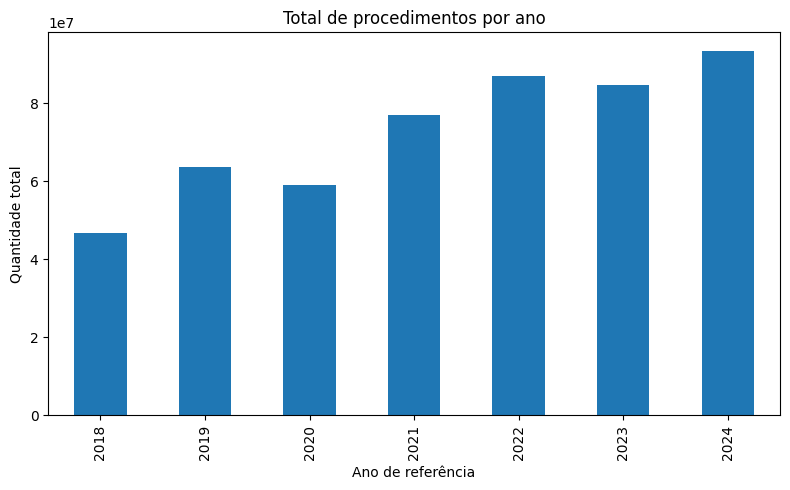

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))
df.groupby('ano_referencia')['quantidade'].sum().sort_index().plot(kind='bar', ax=ax)
ax.set_title('Total de procedimentos por ano')
ax.set_xlabel('Ano de referência')
ax.set_ylabel('Quantidade total')
plt.tight_layout()
plt.show()

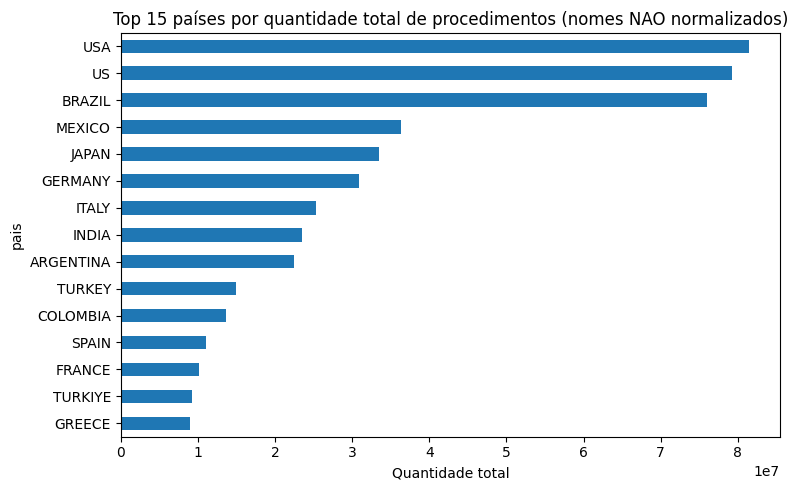

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))
df.groupby('pais')['quantidade'].sum().sort_values(ascending=False).head(15).plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_title('Top 15 países por quantidade total de procedimentos (nomes NAO normalizados)')
ax.set_xlabel('Quantidade total')
plt.tight_layout()
plt.show()

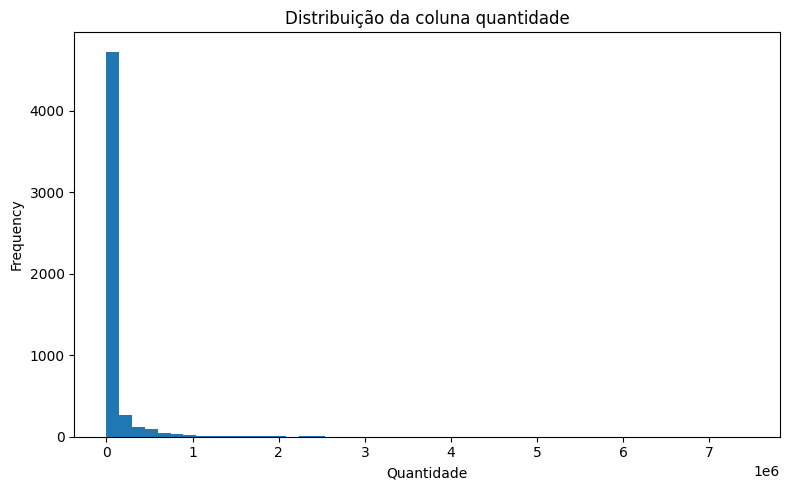

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))
df['quantidade'].plot(kind='hist', bins=50, ax=ax)
ax.set_title('Distribuição da coluna quantidade')
ax.set_xlabel('Quantidade')
plt.tight_layout()
plt.show()

## 11. Conclusões — transformações necessárias para a Silver

- **Deduplicação:** remover linhas totalmente repetidas (ver seção 4).
- **Nulos em `quantidade`:** descartar — procedimento não reportado por aquele país naquele ano (mesma regra já usada antes na Silver).
- **Normalização de país:** aplicar dicionário para unificar variantes (`USA`/`US`, `UK`/`UNITED KINGDOM`, `TURKEY`/`TURKIYE`) — ver seção 6.1. Sem isso, os totais por país sub-representam o país "correto" e o distorcem em análises agregadas.
- **Tradução de `procedimento`/`categoria` para PT-BR:** viável e recomendada, via dicionário de mapeamento, preservando o termo original em inglês numa coluna auxiliar (ver seção 8).
- **Validação de schema:** reaplicar `pandera` (tipos, `quantidade >= 0`, `tipo_procedimento` restrito a `{CIRURGICO, NAO-CIRURGICO}`) como última etapa antes de gravar a Silver.